# EDA — RSNA Knee Abnormality Detection

Rodar depois de `bash scripts/download_data.sh` (baixa os CSVs por padrão). Objetivo: confirmar a cobertura de labels, distribuicao das classes, estrutura de series/planos, e o texto dos laudos.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from pathlib import Path
from src.rsna_knee import config

pd.set_option('display.max_columns', 50)

## 1. train.csv — cobertura de labels

Só uma parte dos estudos tem as 12 colunas de label preenchidas. Checar aqui quantos.

In [2]:
train_df = pd.read_csv(config.TRAIN_CSV)
print('total de estudos:', len(train_df))

labeled = train_df.dropna(subset=config.TARGET_COLUMNS)
print('estudos com label completo:', len(labeled), f'({len(labeled)/len(train_df)*100:.1f}%)')
train_df.head()

total de estudos: 4407
estudos com label completo: 58 (1.3%)


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Distribuicao dos 12 labels (só nos estudos com label)

Essencial pra saber o quao desbalanceado esta cada classe.

In [3]:
label_counts = labeled[config.TARGET_COLUMNS].sum().sort_values(ascending=False)
label_rate = (label_counts / len(labeled) * 100).round(1)
pd.DataFrame({'positivos': label_counts, 'taxa_%': label_rate})

,positivos,taxa_%
Effusion,35.0,60.3
Synovitis,27.0,46.6
Medial Meniscus,26.0,44.8
ACL,24.0,41.4
Lateral Meniscus,23.0,39.7
PF OA,21.0,36.2
Contusion,19.0,32.8
Fracture,18.0,31.0
Medial OA,15.0,25.9
Baker's,12.0,20.7


<Axes: title={'center': '% de casos positivos por label (entre os estudos com label)'}>

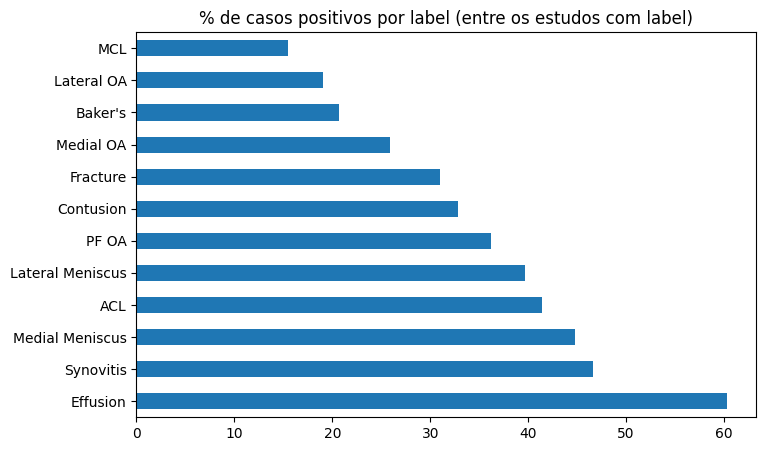

In [4]:
label_rate.plot(kind='barh', figsize=(8, 5), title='% de casos positivos por label (entre os estudos com label)')

## 3. train_series.csv — quantas series por estudo, planos anatomicos

In [5]:
series_df = pd.read_csv(config.TRAIN_SERIES_CSV)
print('total de series:', len(series_df))
print()
print('series por estudo:')
print(series_df.groupby(config.ID_COLUMN).size().describe())
print()
print('planos anatomicos:')
print(series_df['Anatomical_Plane'].value_counts())
print()
print('fluid sensitive:', series_df['Fluid_Sensitive'].mean().round(2))
print('fat suppression:', series_df['Fat_Suppression'].mean().round(2))

total de series: 24371

series por estudo:
count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64

planos anatomicos:
Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

fluid sensitive: 0.57
fat suppression: 0.57


## 4. Texto dos laudos (Report)

Checar cobertura, idiomas aproximados (pelo tamanho/caracteres), tamanho medio.

**Lembrete importante**: `test.csv` NAO tem coluna `Report` — o texto so existe no treino. Ver CLAUDE.md.

In [6]:
has_report = train_df['Report'].notna()
print(f'estudos com Report preenchido: {has_report.sum()} ({has_report.mean()*100:.1f}%)')

lens = train_df['Report'].dropna().str.len()
print(lens.describe())
print()
print('Exemplo de laudo:')
print(train_df['Report'].dropna().iloc[0])

estudos com Report preenchido: 4407 (100.0%)
count    4407.000000
mean     1097.905605
std       693.948925
min        52.000000
25%       587.500000
50%       977.000000
75%      1459.500000
max      4743.000000
Name: Report, dtype: float64

Exemplo de laudo:
Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame.


## 5. Estudos sem label mas com Report

Sao candidatos a weak supervision (derivar labels do texto). Quantos sao?

In [7]:
no_label_has_report = train_df[train_df[config.TARGET_COLUMNS].isna().any(axis=1) & train_df['Report'].notna()]
print(f'estudos sem label completo mas com Report: {len(no_label_has_report)}')

estudos sem label completo mas com Report: 4349


## 6. Visualizar um slice de exemplo

Só roda se voce ja tiver baixado pelo menos um estudo de imagens (`train_series/<StudyInstanceUID>/...`). Se so baixou os CSVs ainda, pule esta celula.

In [ ]:
import matplotlib.pyplot as plt
from src.rsna_knee.data.dataset import load_study_image

sample_study = labeled[config.ID_COLUMN].iloc[0]
study_dir = config.TRAIN_SERIES_DIR / str(sample_study)

if study_dir.exists():
    series_df = pd.read_csv(config.TRAIN_SERIES_CSV)
    img = load_study_image(study_dir, sample_study, series_df)
    plt.imshow(img[0], cmap='gray')
    plt.title(str(sample_study))
    plt.axis('off')
else:
    print(f'Pasta nao encontrada ainda: {study_dir}')
    print('Baixe as imagens desse estudo especifico ou rode com --full em scripts/download_data.sh')

## Proximos passos

- [ ] Decidir estrategia de texto (image-only vs. text-dropout) — ver CLAUDE.md
- [ ] Decidir estrategia de selecao de serie/slice em `src/rsna_knee/data/` com base no que apareceu na secao 3
- [ ] Rodar `python -m src.rsna_knee.cli.train` numa amostra pequena pra validar o pipeline
- [ ] Levar o pipeline validado para um Kaggle Notebook com GPU